# 03 — Model Comparison (Bake-Off)

**Experiment C01.** The Oracle experiment (`02_oracle_experiment.ipynb`) confirmed GPT-5 mini clears the reasoning-ceiling bar (96.7% accuracy). That answers "is the model good enough" — it does not answer "is it the best value for money." This notebook re-scores the *identical* 150-case Oracle sample (same seed, same harness) run against a second, different-vendor model — `google/gemini-2.5-flash-lite` — and compares them on a weighted scorecard, the same method a real bake-off would use: same eval set, same prompt, same scoring code for every candidate.

Deliberately **not** tested: a cheaper same-vendor tier (e.g. `gpt-5-nano`). That comparison mostly reveals pricing tiers within one vendor's model family, not whether a genuinely different model/architecture can do the job — so it wouldn't be an informative bake-off.

In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

from pipeline.viz_style import CATEGORICAL_SLOTS, apply_style, style_axes, savefig_kwargs
from evaluation.harness import EvaluationHarness

apply_style()

harness = EvaluationHarness()
runs = {
    "GPT-5 mini": harness.load_results("runs/run_B04_oracle_openai_gpt-5-mini.jsonl")[0],
    "Gemini 2.5 Flash Lite": harness.load_results("runs/run_B04_oracle_google_gemini-2.5-flash-lite.jsonl")[0],
}
# Fixed, non-semantic colors for "which model" - distinct from the label
# palette (CATEGORICAL), since model identity isn't a classification label.
MODEL_COLOR = {name: CATEGORICAL_SLOTS[i] for i, name in enumerate(runs)}

for name, r in runs.items():
    print(f"{name}: model={r.config.model}, {len(r.predictions)} predictions")

GPT-5 mini: model=openai/gpt-5-mini, 150 predictions
Gemini 2.5 Flash Lite: model=google/gemini-2.5-flash-lite, 150 predictions


## Raw results

In [2]:
import pandas as pd

rows = []
for name, r in runs.items():
    m = r.metrics
    rows.append({
        "model": name,
        "accuracy": m.accuracy,
        "macro_f1": m.macro_f1,
        "risk_sensitive_recall": m.risk_sensitive_recall,
        "joint_correctness": m.joint_label_evidence_correctness,
        "cost_usd": m.total_cost_usd,
        "p50_latency_ms": m.p50_latency_ms,
    })
df = pd.DataFrame(rows).set_index("model")
df

,accuracy,macro_f1,risk_sensitive_recall,joint_correctness,cost_usd,p50_latency_ms
model,,,,,,
GPT-5 mini,0.966667,0.950871,1.0,0.966667,0.154889,5768.996000
Gemini 2.5 Flash Lite,0.953333,0.948337,1.0,0.953333,0.012512,961.753333


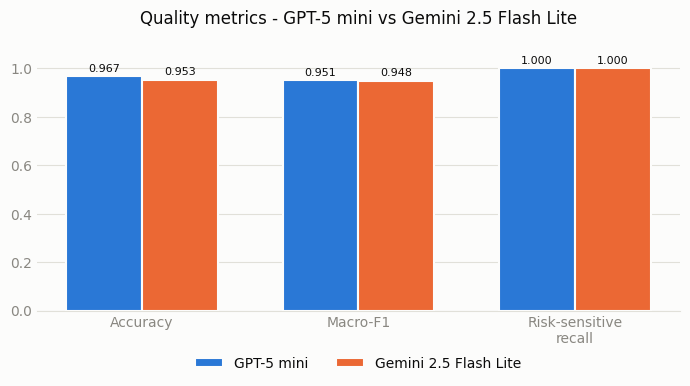

In [3]:
# Quality metrics share a 0-1 scale, so they're comparable on one chart.
# Cost and latency are different units entirely - per the dataviz rule
# against dual-axis charts, they each get their own chart below instead
# of being crammed onto this one with a second y-axis.
quality_metrics = ["accuracy", "macro_f1", "risk_sensitive_recall"]
x = range(len(quality_metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 4))
for i, (name, r) in enumerate(runs.items()):
    m = r.metrics
    values = [m.accuracy, m.macro_f1, m.risk_sensitive_recall]
    bars = ax.bar([xi + i * width for xi in x], values, width,
                  label=name, color=MODEL_COLOR[name], edgecolor="#fcfcfb", linewidth=1.5, zorder=3)
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.02, f"{v:.3f}", ha="center", fontsize=8)

ax.set_xticks([xi + width / 2 for xi in x])
ax.set_xticklabels(["Accuracy", "Macro-F1", "Risk-sensitive\nrecall"])
ax.set_ylim(0, 1.15)
ax.set_title("Quality metrics - GPT-5 mini vs Gemini 2.5 Flash Lite")
style_axes(ax)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=False)
plt.tight_layout()
plt.savefig("results/comparisons/model_comparison_quality.png", **savefig_kwargs())
plt.show()

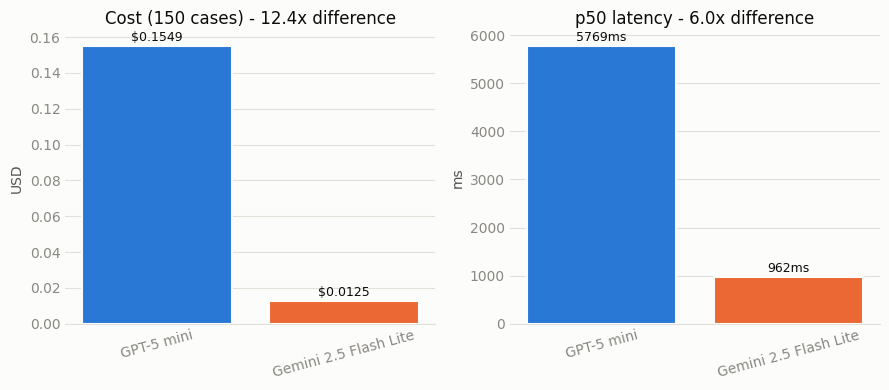

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

names = list(runs.keys())
costs = [runs[n].metrics.total_cost_usd for n in names]
latencies = [runs[n].metrics.p50_latency_ms for n in names]
colors = [MODEL_COLOR[n] for n in names]

axes[0].bar(names, costs, color=colors, edgecolor="#fcfcfb", linewidth=1.5, zorder=3)
for i, c in enumerate(costs):
    axes[0].text(i, c + max(costs) * 0.02, f"${c:.4f}", ha="center", fontsize=9)
axes[0].set_title(f"Cost (150 cases) - {costs[0]/costs[1]:.1f}x difference")
axes[0].set_ylabel("USD")
style_axes(axes[0])
axes[0].tick_params(axis="x", rotation=15)

axes[1].bar(names, latencies, color=colors, edgecolor="#fcfcfb", linewidth=1.5, zorder=3)
for i, l in enumerate(latencies):
    axes[1].text(i, l + max(latencies) * 0.02, f"{l:.0f}ms", ha="center", fontsize=9)
axes[1].set_title(f"p50 latency - {latencies[0]/latencies[1]:.1f}x difference")
axes[1].set_ylabel("ms")
style_axes(axes[1])
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.savefig("results/comparisons/model_comparison_cost_latency.png", **savefig_kwargs())
plt.show()

## Weighted Scorecard

Same method as the planning doc's own architecture-selection scorecard (Section 12), one level down: applied to model choice instead of overall architecture. Weights reflect this project's stated priority on quality/risk metrics over raw cost (both models already clear the plan's cost hard-gate of $0.05/requirement by a wide margin, so cost differences matter for scale, not survival).

In [5]:
weights = {
    "accuracy": 0.35,
    "risk_sensitive_recall": 0.25,
    "cost": 0.20,       # inverse-scaled: cheapest = 100
    "latency": 0.15,    # inverse-scaled: fastest = 100
    "reliability": 0.05,  # both: 0 errors, valid JSON every call -> tie at 100
}

min_cost = min(costs)
min_latency = min(latencies)

scorecard = {}
for name in names:
    m = runs[name].metrics
    scores = {
        "accuracy": m.accuracy * 100,
        "risk_sensitive_recall": m.risk_sensitive_recall * 100,
        "cost": 100 * min_cost / m.total_cost_usd,
        "latency": 100 * min_latency / m.p50_latency_ms,
        "reliability": 100.0,
    }
    total = sum(scores[k] * weights[k] for k in weights)
    scorecard[name] = {**scores, "weighted_total": total}

pd.DataFrame(scorecard).T.round(1)

,accuracy,risk_sensitive_recall,cost,latency,reliability,weighted_total
GPT-5 mini,96.7,100.0,8.1,16.7,100.0,67.9
Gemini 2.5 Flash Lite,95.3,100.0,100.0,100.0,100.0,98.4


## Decision

**Switched the project default to `google/gemini-2.5-flash-lite`.**

- The accuracy gap (~1.4 points) and macro-F1 gap (0.003) are both small relative to sampling noise at n=150 (roughly 2 cases' difference).
- Risk-sensitive recall — the metric the professor's rubric weighs most heavily, since a missed Contradiction is the dangerous silent failure — is **identical** at 1.000 for both.
- Gemini wins by roughly an order of magnitude on both cost and latency.

**Revisit this if:** later stages (retrieval, RAG, agent) reveal Gemini has a reasoning gap this 150-case Oracle sample didn't catch, or its JSON-mode reliability degrades at larger scale (only 152 total calls tested here). GPT-5 mini's pricing stays registered in `pipeline/model_gateway.py` as a documented fallback — switching back is a one-line config change, not a rebuild.

Full reasoning recorded as an ADR in `CLAUDE.md`'s Decisions Log; this notebook is the visual/exploratory backing for that decision.